In [70]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [71]:
df= pd.read_csv('/content/online_retail.csv', encoding='latin1')

In [72]:
df.shape

(541910, 8)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [54]:


df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [58]:
df.describe()

,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [82]:
# 2. Handle Missing Values
df = df.dropna(subset=['Customer ID'])


In [76]:
# 3. Feature Engineering: RFM Analysis
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'Invoice': 'count',                                     # Frequency (corrected from InvoiceNo)
    'Quantity': 'sum'                                         # Monetary proxy
})

rfm.rename(columns={
    'InvoiceDate':'Recency',
    'Invoice':'Frequency', # Corrected column name in rename as well
    'Quantity':'Monetary'
}, inplace=True)

print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
12346.0          326          2         0
12347.0            2        182      2458
12348.0           75         31      2341
12349.0           19         73       631
12350.0          310         17       197


In [77]:
# 4. Standardize Features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [78]:
# 5. Apply Clustering Algorithms
# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster_KMeans'] = kmeans.fit_predict(rfm_scaled)

# Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=4)
rfm['Cluster_HC'] = hc.fit_predict(rfm_scaled)

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5) # Adjust eps and min_samples as needed
rfm['Cluster_DBSCAN'] = dbscan.fit_predict(rfm_scaled)

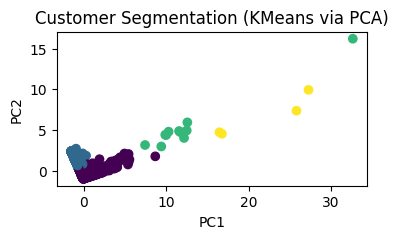

In [81]:
# 6. Visualize Clusters (using PCA for dimensionality reduction)
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(4,2))
plt.scatter(rfm_pca[:,0], rfm_pca[:,1], c=rfm['Cluster_KMeans'], cmap='viridis')
plt.title("Customer Segmentation (KMeans via PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [80]:
# 7. Interpret Segments
print(rfm.groupby('Cluster_KMeans').mean())

                   Recency    Frequency      Monetary  Cluster_HC  \
Cluster_KMeans                                                      
0                40.287948   104.203005   1139.451702    1.989880   
1               247.244526    27.710766    260.654197    1.019161   
2                 5.727273  1181.545455  69533.636364    0.000000   
3                 2.000000  5914.000000  35147.500000    3.000000   

                Cluster_DBSCAN  
Cluster_KMeans                  
0                    -0.001227  
1                     0.000000  
2                    -1.000000  
3                    -1.000000  
